# 09 — Annotate the significant hits from `08_cps_mixed_models.ipynb`

Restricted to the directions `08_cps_mixed_models.ipynb` calls `supported_local` or
`supported_global` -- currently 24 of 124, all from the global family. Nothing here is
recomputed from the embedding: `07_annotation.ipynb`'s existing supertype/region/gene/
GO-enrichment tables and scCODA compositional join are reused and filtered down to this
smaller set, and `07_annotation.ipynb`'s CPS effect columns (`CPS_slope_bayes` /
`CPS_p_positive`, from `archive/06_hierarchical_bayes.ipynb`'s Bayesian VI fit) are
dropped in favor of `08_cps_mixed_models.ipynb`'s own frequentist estimates.

**Data**: `08_cps_mixed_models.ipynb`'s `cps_mixed_models_*.parquet` caches and
`07_annotation.ipynb`'s `direction_annotation_sccoda.parquet` / `ora_all_directions.parquet`
-- run both of those notebooks first.


In [1]:
from __future__ import annotations

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

import sst_drvi as S

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 60)

PSEUDO_DIR = S.SCRATCH / "pseudobulk"
CACHE_DIR = S.SCRATCH / "annotation"
Q_THRESHOLD = 0.05  # matches 08_cps_mixed_models.ipynb's own threshold


## 1 — Load 08's hits


In [2]:
required = [
    "cps_mixed_models_primary.parquet",
    "cps_mixed_models_local_heterogeneity.parquet",
    "cps_mixed_models_global_heterogeneity.parquet",
    "cps_mixed_models_global_heterogeneity_regional.parquet",
    "cps_mixed_models_pathology.parquet",
]
missing = [f for f in required if not (PSEUDO_DIR / f).exists()]
if missing:
    raise FileNotFoundError(f"missing {missing} in {PSEUDO_DIR} -- run 08_cps_mixed_models.ipynb first")

primary = pd.read_parquet(PSEUDO_DIR / "cps_mixed_models_primary.parquet").set_index("direction")
local_heterogeneity = pd.read_parquet(PSEUDO_DIR / "cps_mixed_models_local_heterogeneity.parquet")
global_heterogeneity = pd.read_parquet(PSEUDO_DIR / "cps_mixed_models_global_heterogeneity.parquet")
global_heterogeneity_regional = pd.read_parquet(PSEUDO_DIR / "cps_mixed_models_global_heterogeneity_regional.parquet")
pathology = pd.read_parquet(PSEUDO_DIR / "cps_mixed_models_pathology.parquet").set_index("direction")

hits = primary.index[primary["supported_local"] | primary["supported_global"]]
print(
    f"{len(hits)}/{len(primary)} directions supported by 08_cps_mixed_models.ipynb "
    f"({int(primary['supported_local'].sum())} local, {int(primary['supported_global'].sum())} global)"
)


24/124 directions supported by 08_cps_mixed_models.ipynb (0 local, 24 global)


## 2 — Join existing supertype/region/gene/GO annotation

`07_annotation.ipynb`'s `direction_annotation_sccoda.parquet` already computed supertype
specificity, region specificity, top genes, top GO/Hallmark terms, and scCODA
compositional credibility for all 124 directions -- restricting to `hits` here is a
filter, not a recomputation.


In [3]:
annotation_path = CACHE_DIR / "direction_annotation_sccoda.parquet"
if not annotation_path.exists():
    raise FileNotFoundError(f"{annotation_path} missing -- run 07_annotation.ipynb first")

annotation = pd.read_parquet(annotation_path)
bayes_columns = ["CPS_slope_bayes", "CPS_p_positive", "sigma_beta_CPS", "mu_beta_CPS", "abs_cps"]
annotation = annotation.drop(columns=[c for c in bayes_columns if c in annotation.columns])

missing_from_annotation = [d for d in hits if d not in annotation.index]
if missing_from_annotation:
    print(
        f"{len(missing_from_annotation)} hit(s) not in 07's annotation cache "
        f"(re-run 07_annotation.ipynb if the embedding changed): {missing_from_annotation}"
    )

hit_annotation = annotation.reindex(hits).join(primary.reindex(hits))
print(f"{len(hit_annotation)} hits annotated")


24 hits annotated


## 3 — Regional heterogeneity and amyloid/tau, for the hits

Both already computed in `08_cps_mixed_models.ipynb` sections 3 and 5, restricted there
to exactly this set of directions -- attached here, not recomputed.


In [4]:
local_q = local_heterogeneity.set_index("direction")["q"] if len(local_heterogeneity) else pd.Series(dtype=float)
global_q = global_heterogeneity.set_index("direction")["q"] if len(global_heterogeneity) else pd.Series(dtype=float)

hit_annotation["local_heterogeneity_q"] = local_q.reindex(hits)
hit_annotation["global_heterogeneity_q"] = global_q.reindex(hits)
hit_annotation["local_heterogeneous"] = hit_annotation["local_heterogeneity_q"] < Q_THRESHOLD
hit_annotation["global_heterogeneous"] = hit_annotation["global_heterogeneity_q"] < Q_THRESHOLD

print(
    f"{int(hit_annotation['global_heterogeneous'].sum())}/{len(hits)} hits show significant "
    "region x global_cps heterogeneity"
)
if len(local_heterogeneity):
    print(
        f"{int(hit_annotation['local_heterogeneous'].sum())}/{len(hits)} hits show significant "
        "region x local_within heterogeneity"
    )

pathology_columns = [
    "beta_abeta_local_joint", "beta_ptau_local_joint", "local_contrast_diff", "local_contrast_p",
    "beta_abeta_global_joint", "beta_ptau_global_joint", "global_contrast_diff", "global_contrast_p",
]
hit_annotation = hit_annotation.join(
    pathology.reindex(hits)[[c for c in pathology_columns if c in pathology.columns]]
)
n_pathology = pathology.reindex(hits)["beta_abeta_global_joint"].notna().sum() if "beta_abeta_global_joint" in pathology.columns else 0
print(f"{n_pathology}/{len(hits)} hits carried into 08's amyloid/tau follow-up")


12/24 hits show significant region x global_cps heterogeneity
24/24 hits carried into 08's amyloid/tau follow-up


## 4 — scCODA reclassification with 08's own significance

`07_annotation.ipynb` classified a direction as co-lost/counter using the Bayesian
`p_positive`; the same compositional logic is checked here against `08`'s own
`q_global` (or `q_local`, for the directions supported only through `local_within`).


In [5]:
cps_beta = hit_annotation["beta_global"]
cps_significant = hit_annotation["supported_global"]
# Fall back to the local effect for directions supported only through local_within.
local_only = hit_annotation["supported_local"] & ~hit_annotation["supported_global"]
cps_beta = cps_beta.where(~local_only, hit_annotation["beta_local"])
cps_significant = cps_significant | hit_annotation["supported_local"]

co_lost = hit_annotation["st_credible"] & (cps_beta < 0) & cps_significant
counter = hit_annotation["st_credible"] & (cps_beta > 0) & cps_significant
no_credible = ~hit_annotation["st_credible"] & cps_significant

hit_annotation["cps_beta_used"] = cps_beta
hit_annotation["co_lost"] = co_lost
hit_annotation["counter"] = counter

print(f"hits with a credible-scCODA primary supertype: {int(hit_annotation['st_credible'].sum())}/{len(hits)}")
print(f"  co-lost (direction down as supertype depleted): {int(co_lost.sum())}")
print(f"  counter (direction up as supertype depleted): {int(counter.sum())}")
print(f"  no credible primary-supertype link (candidate cell-intrinsic): {int(no_credible.sum())}")


hits with a credible-scCODA primary supertype: 7/24
  co-lost (direction down as supertype depleted): 7
  counter (direction up as supertype depleted): 0
  no credible primary-supertype link (candidate cell-intrinsic): 17


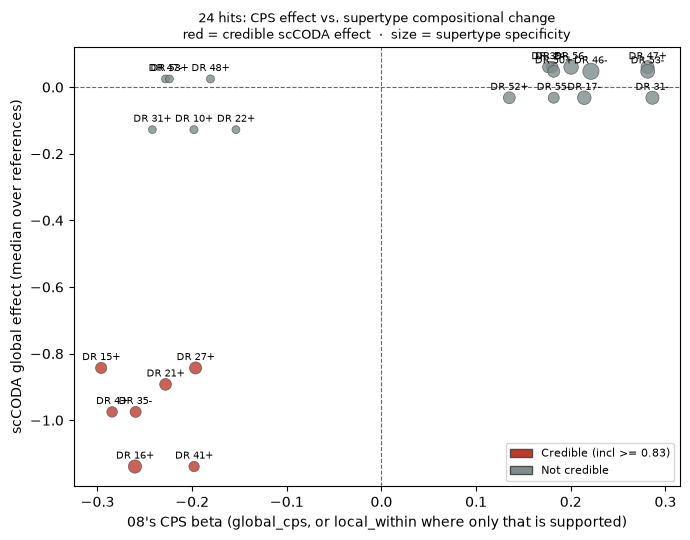

In [6]:
# Scatter: CPS beta (x) vs scCODA effect (y). Small N here (a couple dozen hits at
# most), so every point is labelled rather than only the "strong" subset 07 singles out.
have_sccoda = hit_annotation["sccoda_effect"].notna()
sub = hit_annotation[have_sccoda]

color = np.where(sub["st_credible"], "#c0392b", "#7f8c8d")
size = sub["specificity"].astype(float) * 150 + 20

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(sub["cps_beta_used"], sub["sccoda_effect"], c=color, s=size,
           alpha=0.8, edgecolors="0.3", linewidths=0.5)
for direction, row in sub.iterrows():
    ax.annotate(direction, (row["cps_beta_used"], row["sccoda_effect"]),
                fontsize=7, ha="center", va="bottom", xytext=(0, 4), textcoords="offset points")
ax.axhline(0, color="0.4", lw=0.8, ls="--")
ax.axvline(0, color="0.4", lw=0.8, ls="--")
ax.set_xlabel("08's CPS beta (global_cps, or local_within where only that is supported)")
ax.set_ylabel("scCODA global effect (median over references)")
ax.set_title(
    f"{len(sub)} hits: CPS effect vs. supertype compositional change\n"
    "red = credible scCODA effect  ·  size = supertype specificity", fontsize=9,
)
legend_els = [
    Patch(fc="#c0392b", ec="0.3", label=f"Credible (incl >= {S.SCCODA_INCLUSION_THRESHOLD})"),
    Patch(fc="#7f8c8d", ec="0.3", label="Not credible"),
]
ax.legend(handles=legend_els, fontsize=8)
fig.tight_layout()
plt.show()


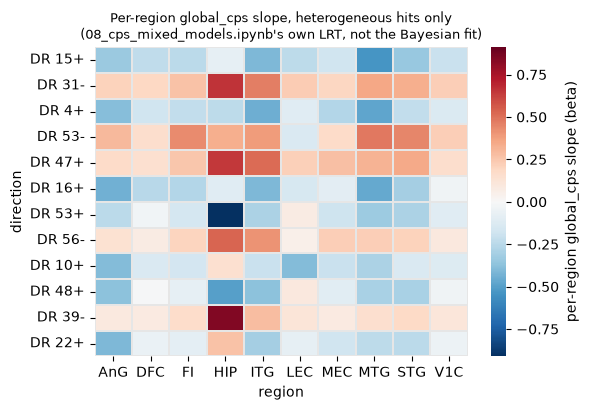

In [7]:
# Per-region global_cps slope for the heterogeneous hits, from 08's own LRT --
# the frequentist equivalent of 07_annotation.ipynb's Bayesian per-region heatmap.
heterogeneous_hits = hit_annotation.index[hit_annotation["global_heterogeneous"]]
if len(heterogeneous_hits):
    regional = global_heterogeneity_regional[global_heterogeneity_regional["direction"].isin(heterogeneous_hits)]
    matrix = regional.pivot(index="direction", columns="region", values="beta")
    order = hit_annotation.loc[matrix.index, "beta_global"].abs().sort_values(ascending=False).index
    matrix = matrix.reindex(order)

    fig, ax = plt.subplots(figsize=(6, max(3, len(matrix) * 0.35)))
    vabs = float(matrix.abs().to_numpy().max())
    sns.heatmap(
        matrix, cmap="RdBu_r", center=0, vmin=-vabs, vmax=vabs,
        linewidths=0.3, linecolor="0.9",
        cbar_kws={"label": "per-region global_cps slope (beta)"}, ax=ax,
    )
    ax.set_title(
        "Per-region global_cps slope, heterogeneous hits only\n"
        "(08_cps_mixed_models.ipynb's own LRT, not the Bayesian fit)", fontsize=9,
    )
    fig.tight_layout()
    plt.show()
else:
    print("no globally-heterogeneous hits to plot")


## 5 — Gene-set enrichment for the hits

Reuses `07_annotation.ipynb`'s cached `ora_all_directions.parquet` -- gseapy is not run
again here, this only subsets the existing results to `hits`.


In [8]:
ora_path = CACHE_DIR / "ora_all_directions.parquet"
if not ora_path.exists():
    raise FileNotFoundError(f"{ora_path} missing -- run 07_annotation.ipynb first")

ora = pd.read_parquet(ora_path)
ora_hits = ora[ora["direction"].isin(hits)]
significant = ora_hits[ora_hits["Adjusted P-value"] < 0.05].copy()
print(
    f"{len(significant):,} significant direction-term pairs among the hits (adj p < 0.05), "
    f"covering {significant['direction'].nunique()}/{len(hits)} hits"
)


1,091 significant direction-term pairs among the hits (adj p < 0.05), covering 18/24 hits


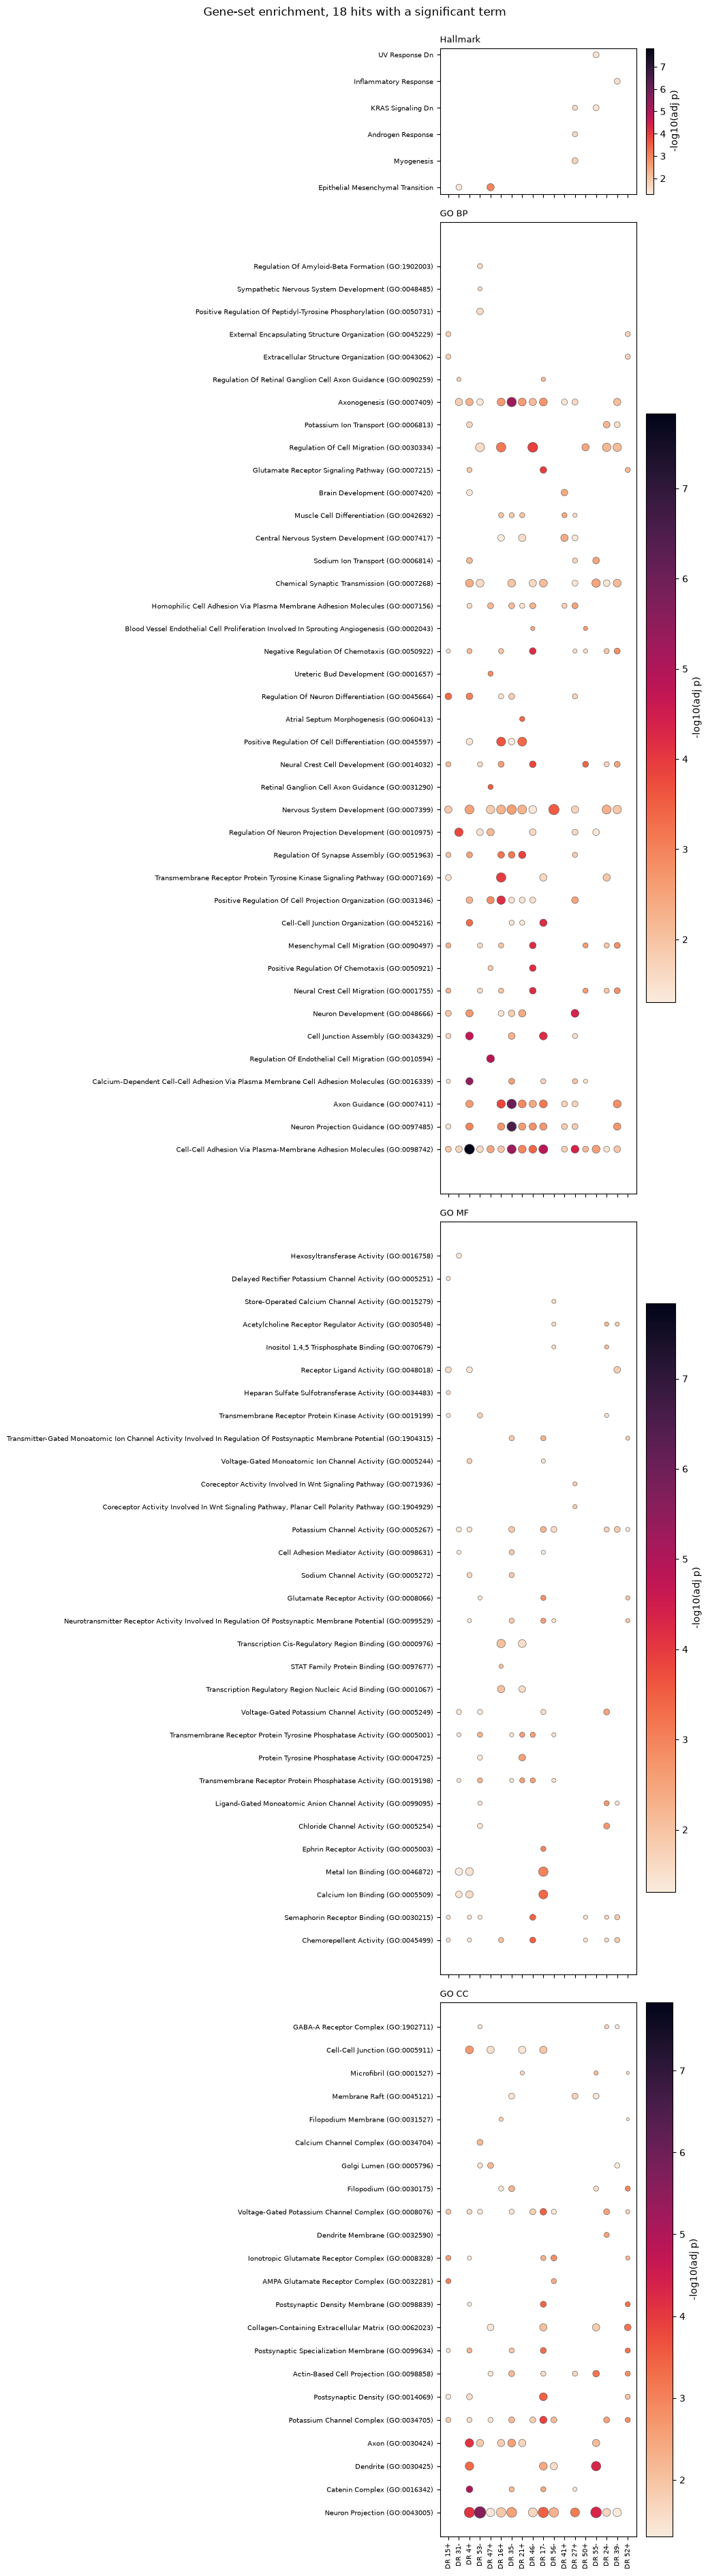

In [9]:
PER_DIRECTION = 3

panels = {}
for label in significant["collection"].unique():
    sub = significant[significant["collection"] == label]
    top_terms = sub.sort_values("Adjusted P-value").groupby("direction", observed=True).head(PER_DIRECTION)
    terms = top_terms["Term"].drop_duplicates().tolist()
    panels[label] = (sub[sub["Term"].isin(terms)], terms)

if not panels:
    print("no significant enrichment among the hits")
else:
    order = (
        hit_annotation.reindex([d for d in hits if d in significant["direction"].values])["beta_global"]
        .abs().sort_values(ascending=False).index.tolist()
    )
    rows = [len(terms) for _, terms in panels.values()]
    fig, axes = plt.subplots(
        len(panels), 1, squeeze=False, layout="constrained",
        figsize=(max(8, len(order) * 0.35 + 4), 0.32 * sum(rows) + 1.4 * len(panels)),
        gridspec_kw={"height_ratios": rows},
    )
    limits = -np.log10(significant["Adjusted P-value"])
    for ax, (label, (sub, terms)) in zip(axes[:, 0], panels.items()):
        x_map = {d: i for i, d in enumerate(order)}
        present = sub[sub["direction"].isin(x_map)]
        x = [x_map[d] for d in present["direction"]]
        y = [terms.index(t) for t in present["Term"]]
        sc = ax.scatter(
            x, y, s=present["Overlap"].str.split("/").str[0].astype(int) * 10,
            c=-np.log10(present["Adjusted P-value"]), cmap="rocket_r",
            vmin=limits.min(), vmax=limits.max(), edgecolor="0.3", linewidth=0.4,
        )
        ax.set_xticks(range(len(order)))
        if ax is axes[-1, 0]:
            ax.set_xticklabels(order, rotation=90, fontsize=7)
        else:
            ax.set_xticklabels([])
        ax.set_yticks(range(len(terms)))
        ax.set_yticklabels(terms, fontsize=7)
        ax.set_xlim(-0.8, len(order) - 0.2)
        ax.set_title(label, fontsize=9, loc="left")
        fig.colorbar(sc, ax=ax, label="-log10(adj p)")
    fig.suptitle(f"Gene-set enrichment, {len(order)} hits with a significant term", y=1.01)
    plt.show()


## 6 — Final table and write


In [10]:
display_columns = [
    "beta_local", "q_local", "supported_local",
    "beta_global", "q_global", "supported_global",
    "local_heterogeneous", "global_heterogeneous",
    "primary_supertype", "specificity", "sccoda_effect", "st_credible", "co_lost", "counter",
    "primary_region", "region_specificity",
    "top_genes", "top_GO_BP", "top_Hallmark",
]
hit_table = hit_annotation[[c for c in display_columns if c in hit_annotation.columns]].sort_values("q_global")
hit_table


,beta_local,q_local,supported_local,beta_global,q_global,supported_global,local_heterogeneous,global_heterogeneous,primary_supertype,specificity,sccoda_effect,st_credible,co_lost,counter,primary_region,region_specificity,top_genes,top_GO_BP,top_Hallmark
direction,,,,,,,,,,,,,,,,,,,
DR 53-,0.010541,0.922717,False,0.281229,0.002334,True,False,True,Sst_1,0.529,0.047464,False,False,False,FI,0.160,"PTPRC, AC046195.2, RIT2, MAML3, AC109466.1, SLC35F3, CNT...",Axon Extension Involved In Axon Guidance (GO:0048846),
DR 16+,-0.050462,0.723057,False,-0.260397,0.004896,True,False,True,Sst_23,0.470,-1.138891,True,True,False,STG,0.152,"MSR1, AC011586.2, ANKRD30B, SORCS1, SNTG2, ZBTB20, KIRRE...",Positive Regulation Of Cell Projection Organization (GO:...,
DR 52+,0.036789,0.723057,False,0.135057,0.004896,True,False,False,Sst_5,0.352,-0.031895,False,False,False,HIP,0.299,"AL391832.4, PRR16, COL19A1, ADAMTS20, GRID2, ZNF385D, NE...",Glutamate Receptor Signaling Pathway (GO:0007215),
DR 15+,-0.028070,0.820622,False,-0.296097,0.004896,True,False,True,Sst_2,0.301,-0.843004,True,True,False,V1C,0.152,"HPSE2, ZNF804A, ERBB4, TAFA4, HS6ST3, BTBD11, EYS, COL12A1",Regulation Of Neuron Differentiation (GO:0045664),
DR 41+,0.081236,0.542171,False,-0.197949,0.005759,True,False,False,Sst_23,0.238,-1.138891,True,True,False,LEC,0.177,"RMST, IQCJ-SCHIP1, LINGO2, MSR1, PRKD1, AC011586.2, DMD,...",Brain Development (GO:0007420),
DR 47+,-0.037378,0.770502,False,0.281124,0.005759,True,False,True,Sst_7,0.459,0.060167,False,False,False,MEC,0.163,"PLXDC2, LRRC4C, GDNF-AS1, GPC3, AL589740.1, PTPRK, KHDRB...",Regulation Of Endothelial Cell Migration (GO:0010594),Epithelial Mesenchymal Transition
DR 4+,-0.035973,0.770502,False,-0.284566,0.005759,True,False,True,Sst_20,0.252,-0.974855,True,True,False,FI,0.153,"MME, CDH12, ZNF385D, ZNF536, THSD7A, KIRREL3, LRP1B, FAT4",Cell-Cell Adhesion Via Plasma-Membrane Adhesion Molecule...,
DR 27+,-0.034152,0.770502,False,-0.196332,0.005759,True,False,False,Sst_2,0.370,-0.843004,True,True,False,V1C,0.232,"ROR1, MME, EYS, HPSE2, PCDH15, EYA4, GPC6, CNTN4",Cell-Cell Adhesion Via Plasma-Membrane Adhesion Molecule...,Myogenesis
DR 31-,-0.011167,0.913403,False,0.286269,0.005759,True,False,True,Sst_5,0.464,-0.031895,False,False,False,MEC,0.158,"F11-AS1, LRRC4C, THSD7B, SPON1, LRRTM4, CSMD1, GPR149, N...",Regulation Of Neuron Projection Development (GO:0010975),Epithelial Mesenchymal Transition


In [11]:
out_path = CACHE_DIR / "cps_hits_annotation.parquet"
hit_annotation.to_parquet(out_path)
hit_annotation.to_csv(str(out_path).replace(".parquet", ".tsv"), sep="\t")
print(f"written to {out_path}")


written to /scratch/sst-drvi/annotation/cps_hits_annotation.parquet


## 7 — Summary


In [12]:
strong = hit_annotation["supported_global"] | hit_annotation["supported_local"]
print(f"{len(hits)} directions annotated")
print(f"  {int(hit_annotation['st_credible'].sum())} have a credible scCODA primary supertype")
print(f"  {int(hit_annotation['co_lost'].sum())} co-lost with a depleted supertype (cell-loss candidates)")
print(f"  {int(hit_annotation['counter'].sum())} increase as their primary supertype is depleted")
print(
    f"  {int((~hit_annotation['st_credible'] & strong).sum())} strong-CPS hits have no credible "
    "compositional link (candidate cell-intrinsic)"
)
print(f"  {int(hit_annotation['global_heterogeneous'].sum())} show region x global_cps heterogeneity")


24 directions annotated
  7 have a credible scCODA primary supertype
  7 co-lost with a depleted supertype (cell-loss candidates)
  0 increase as their primary supertype is depleted
  17 strong-CPS hits have no credible compositional link (candidate cell-intrinsic)
  12 show region x global_cps heterogeneity


## 8 — Hit x supertype activity, with scCODA and global_cps margins

`02_explore.ipynb` section 4 draws a split-direction x Supertype heatmap over all live
directions; this is that same heatmap regenerated for only the `hits`, with two margins
attached so the compositional and CPS evidence sit next to the activity pattern instead of
in a separate table:

- **top margin**: each hit's `beta_global` (08's global_cps slope) -- the same quantity
  `hit_table` sorts on.
- **right margin**: each SST supertype's scCODA `CPS_Local` effect, read straight from the
  delivered summary (`09_sccoda_summary.ipynb`'s `shared_effect`) -- one bar per row, not
  just the primary-supertype value `hit_annotation["sccoda_effect"]` carries per hit.

This is the one place in this notebook that loads the DRVI embedding: nothing upstream
cached a supertype x hit-direction activity matrix, so it is computed here rather than
faked from a coarser cache.


In [13]:
# Same preference order as 02_explore.ipynb / 03_progression.ipynb.
CANDIDATES = ["sst_k64_covar_long", "sst_k64_covar", "sst_k64"]
MODEL = "drvi"

embed_path = next(
    (p for c in CANDIDATES if (p := S.EMBED_DIR / f"{c}_{MODEL}_embed.h5ad").exists()),
    None,
)
if embed_path is None:
    raise FileNotFoundError(f"no DRVI embedding found among {CANDIDATES}")
embed = ad.read_h5ad(embed_path)
print(f"{embed_path.name}: {embed.n_obs:,} nuclei x {embed.n_vars} factors")


def split_by_sign(embed) -> pd.DataFrame:
    """Per-cell relu-magnitude activity of each factor direction.

    Ported from 02_explore.ipynb -- `hits` are directions (``DR n+`` / ``DR n-``), so
    the signed factor value is the wrong thing to average: a hit carried by only one
    side of a factor would be diluted by cells sitting on the other side of zero.
    """
    x = np.asarray(embed.X, dtype=np.float32)
    columns = {}
    for pos, (_, row) in enumerate(embed.var.iterrows()):
        values = x[:, pos]
        columns[f"{row['title']}+"] = np.maximum(values, 0.0)
        columns[f"{row['title']}-"] = np.maximum(-values, 0.0)
    return pd.DataFrame(columns, index=embed.obs_names)


# Indexing with `hits` raises KeyError by itself if this embedding is missing a
# direction 08/09's caches were built from (e.g. the embedding was retrained since).
hit_activity = split_by_sign(embed)[hits].groupby(embed.obs["Supertype"], observed=True).mean()
hit_activity.columns.name = None
print(f"{hit_activity.shape[0]} supertypes x {hit_activity.shape[1]} hit directions")


sst_k64_covar_long_drvi_embed.h5ad: 231,107 nuclei x 64 factors


19 supertypes x 24 hit directions


In [14]:
# The delivered scCODA effect, one value per SST supertype -- read straight from the
# summary rather than `hit_annotation["sccoda_effect"]`, which only carries each hit's
# *primary* supertype and would leave every other row in this heatmap blank.
# Mirrors 09_sccoda_summary.ipynb sections 2-2b (shared_effect): the summary broadcasts
# one region-agnostic effect across a supertype's regions, so the row value is that
# mode, not an average over ten copies of the same number.
sst_supertypes = list(embed.obs["Supertype"].cat.categories)
summary_path = sorted(S.CPS_LOCAL_DIR.glob(S.SCCODA_SUMMARY_GLOB))[-1]
summary = pd.read_csv(summary_path, index_col=0)
per_region = (summary[summary["Cell Type"].isin(sst_supertypes)]
              .pivot(index="Cell Type", columns="Region", values="Local Model"))

sccoda_by_supertype = per_region.apply(
    lambda row: row.dropna().mode().iloc[0] if row.notna().any() else np.nan, axis=1
).rename("sccoda_effect")
print(f"{sccoda_by_supertype.notna().sum()}/{len(sccoda_by_supertype)} SST supertypes have "
      f"an scCODA CPS_Local effect ({int((sccoda_by_supertype != 0).sum())} credible)")


19/19 SST supertypes have an scCODA CPS_Local effect (10 credible)


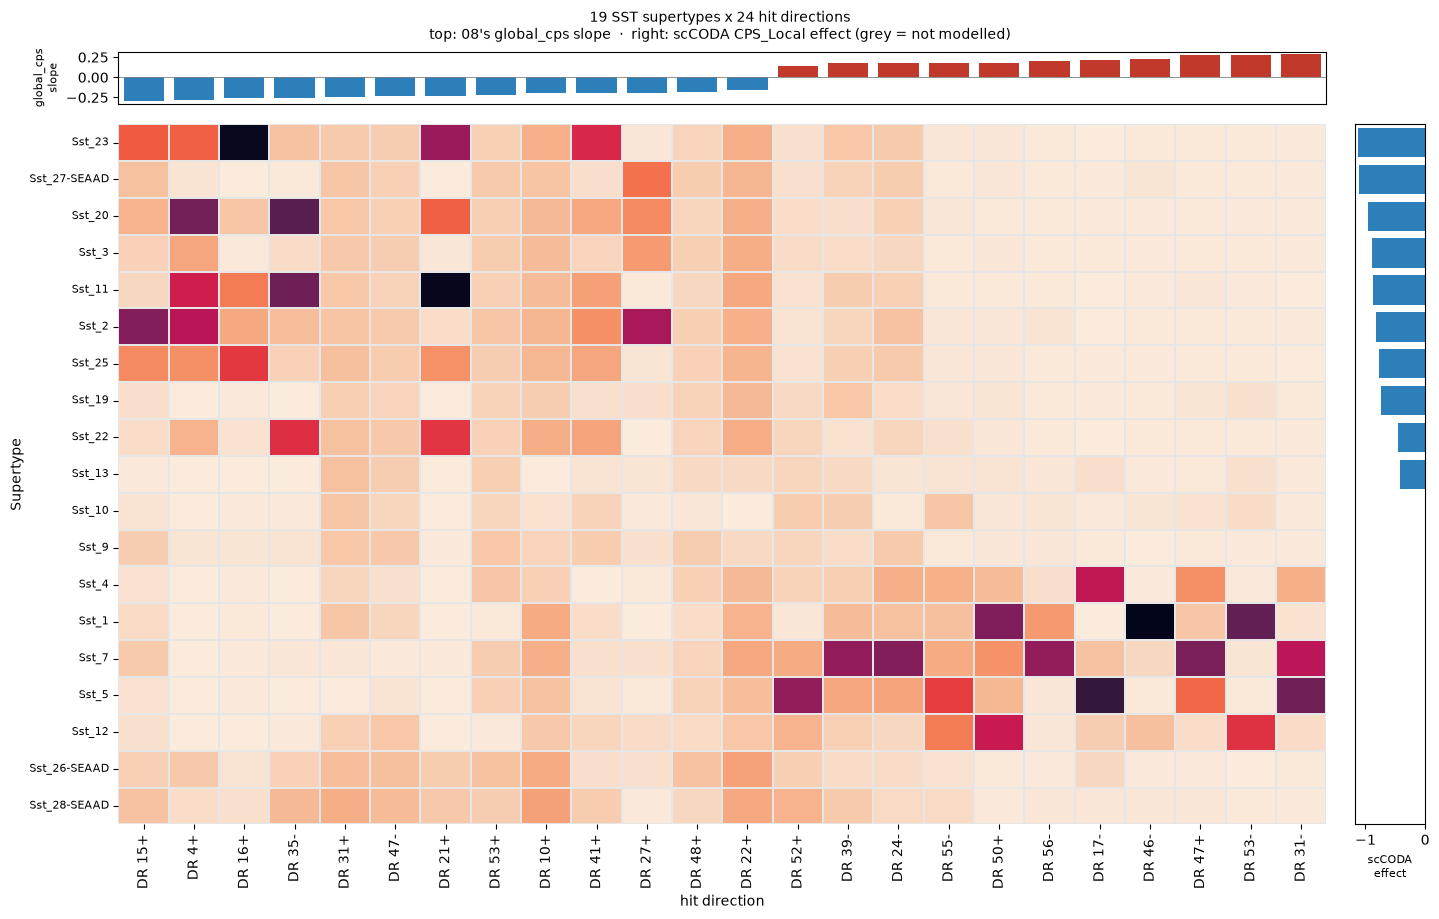

In [15]:
# Columns ordered by beta_global (most depleted-associated to most enriched-associated,
# matching the top margin it is drawn against); rows by the scCODA effect they carry on
# the right margin. Missing scCODA rows (no modelled effect) sort last, not dropped.
col_order = hit_annotation.loc[hit_activity.columns, "beta_global"].sort_values().index
row_order = sccoda_by_supertype.reindex(hit_activity.index).sort_values(
    na_position="last"
).index

matrix = hit_activity.loc[row_order, col_order]
top_values = hit_annotation.loc[col_order, "beta_global"]
right_values = sccoda_by_supertype.loc[row_order]

n_rows, n_cols = matrix.shape
fig = plt.figure(figsize=(0.42 * n_cols + 4.2, 0.32 * n_rows + 3), layout="constrained")
gs = fig.add_gridspec(
    2, 2, width_ratios=[n_cols, 1.4], height_ratios=[1.4, n_rows], wspace=0.04, hspace=0.04
)
ax_top, ax_corner = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
ax_heat = fig.add_subplot(gs[1, 0])
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_heat)
ax_corner.axis("off")

sns.heatmap(matrix, cmap="rocket_r", vmin=0, cbar=False, linewidths=0.3, linecolor="0.9",
            yticklabels=matrix.index.tolist(), ax=ax_heat)
ax_heat.set_xlabel("hit direction")
ax_heat.set_ylabel("Supertype")
ax_heat.tick_params(axis="x", labelrotation=90)
ax_heat.tick_params(axis="y", labelrotation=0, labelsize=8)

x = np.arange(n_cols) + 0.5
ax_top.bar(x, top_values.to_numpy(), width=0.8,
           color=np.where(top_values.to_numpy() < 0, "#2c7fb8", "#c0392b"))
ax_top.set_xlim(0, n_cols)
ax_top.axhline(0, color="0.5", lw=0.6)
ax_top.set_xticks([])
ax_top.set_ylabel("global_cps\nslope", fontsize=8)

right_filled = right_values.fillna(0.0).to_numpy()
y = np.arange(n_rows) + 0.5
ax_right.barh(y, right_filled, height=0.8,
              color=np.where(right_values.isna(), "0.85",
                             np.where(right_filled < 0, "#2c7fb8", "#c0392b")))
ax_right.axvline(0, color="0.5", lw=0.6)
# `ax_right` shares its y-axis with `ax_heat` (so the bars line up with the heatmap
# rows); `set_yticks([])` mutates that *shared* locator and would blank ax_heat's row
# labels too, so hide ax_right's own tick marks/labels via tick_params instead.
ax_right.tick_params(axis="y", left=False, labelleft=False)
ax_right.set_xlabel("scCODA\neffect", fontsize=8)

fig.suptitle(
    f"{n_rows} SST supertypes x {n_cols} hit directions\n"
    "top: 08's global_cps slope  ·  right: scCODA CPS_Local effect (grey = not modelled)",
    fontsize=10,
)
plt.show()
